# Ejercicios de Visualización con Matplotlib y Seaborn

La visualización de datos es una de las herramientas más importantes en el análisis de datos y la ciencia de datos. No solo nos permite explorar y entender mejor los datos, sino que también nos ayuda a comunicar hallazgos de manera efectiva. A través de gráficos, podemos detectar patrones, relaciones y anomalías que serían difíciles de identificar solo con números o tablas.

In [184]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# He estado investigando sobre estilos que se utilizan en ámbito profesional y he encontrado que en cuantto a palettas de colores,
# hay un estudio que recomienda la Okabe-Ito como estándar científico para ayudar a la lectura de datos a personas con daltonismo.
# Para implementar todo esto he encontrado que se puede connfigurar un archivo '.mplstyle' para cargar al inicio de los proyectos
# por eso lo cargo al inicio del proyecto.

plt.style.use('./axelinvest.mplstyle')


# Para el mapa de colores vamos a asignar la paleta divergente a 'okabe_div'. Así en el ejercicio 6 tenemos el mapa ded colores.
okabe_div = sns.diverging_palette(202, 38, as_cmap=True)

## Ejercicio 1 - Gráfico de líneas simple

Supongamos que, en tu oficina, te toma 10 segundos recorrer 25 metros caminando tranquilamente hacia la máquina de café. Si queremos expresar esta situación como una función lineal de la distancia respecto al tiempo, usamos la fórmula:

$
\text{distancia} = \text{velocidad} \times \text{tiempo}
$



Dado que la velocidad es constante, esta representa la pendiente de la función y se puede interpretar como la primera derivada de la distancia con respecto al tiempo. Es decir, nos indica qué tan rápido cambia la distancia mientras pasa el tiempo.

- **Calcula la velocidad constante a la que caminas:** Sabemos que recorriste 25 metros en 10 segundos. ¿Cuál es la velocidad (en metros/segundo)?
- **Construye la función lineal que describe cómo cambia la distancia con el tiempo:** Usa la fórmula `distancia = velocidad × tiempo` para calcular la distancia recorrida en cada segundo desde 0 a 10.
- **Usa Matplotlib para graficar cómo cambia la distancia con el tiempo:** Agrega etiquetas a los ejes y un título al gráfico.

1. La velocidad constante es: 2.5 m/s

2. Distancia recorrida cada segundo:
if time=0s; distance=0.0m
if time=1s; distance=2.5m
if time=2s; distance=5.0m
if time=3s; distance=7.5m
if time=4s; distance=10.0m
if time=5s; distance=12.5m
if time=6s; distance=15.0m
if time=7s; distance=17.5m
if time=8s; distance=20.0m
if time=9s; distance=22.5m
if time=10s; distance=25.0m

3. Gráfico de la función lineal distancia = velocidad * tiempo:


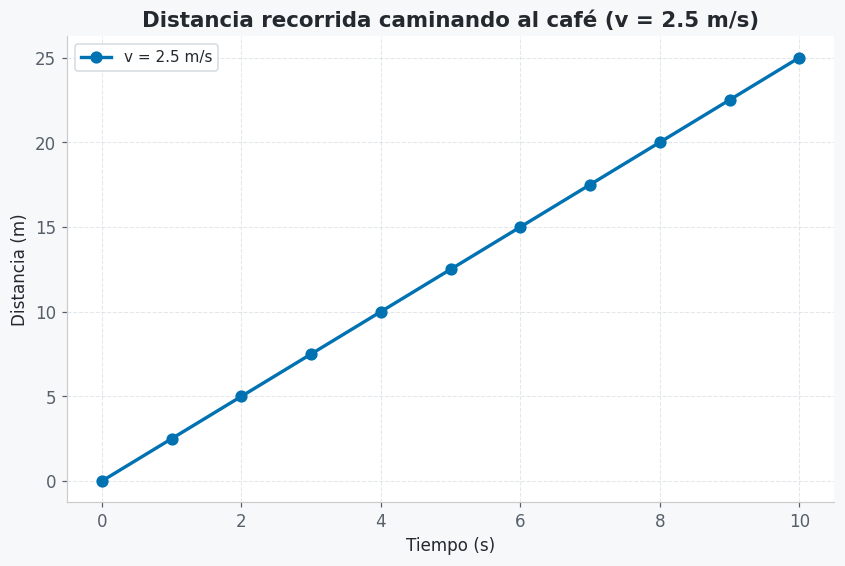

In [186]:
x = np.arange(0, 11) # array con valores de 0 a 10


# 1 - Calculamos la velocidad constante con distancia/tiempo.
velocity_25 = 25 / 10
print(f"1. La velocidad constante es: {velocity_25} m/s")


# 2 - La función lineal constante es paara este ejercicio es:
distance_25 = velocity_25 * x

# He hecho un bucle porque se me ha ocurrido hacerlo y así practico.
print("\n2. Distancia recorrida cada segundo:")
for line in range(len(x)):
    print(f"if time={x[line]}s; distance={distance_25[line]:.1f}m")


# --- Pregunta 3: gráfico ---
print("\n3. Gráfico de la función lineal distancia = velocidad * tiempo:")
plt.plot(x, distance_25, label='v = 2.5 m/s', marker='o')
plt.title('Distancia recorrida caminando al café (v = 2.5 m/s)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.show()

### ¿Qué crees que pasaría con la gráfica si caminaras más rápido o más lento? ¿Cómo cambiaría la pendiente? Prueba modificar la velocidad a 3 m/s y vuelve a graficar.

Al aumentar la velocidad, la pendiente de la recta augmenta de valor linealmente, como se puede ver en el gráfico.



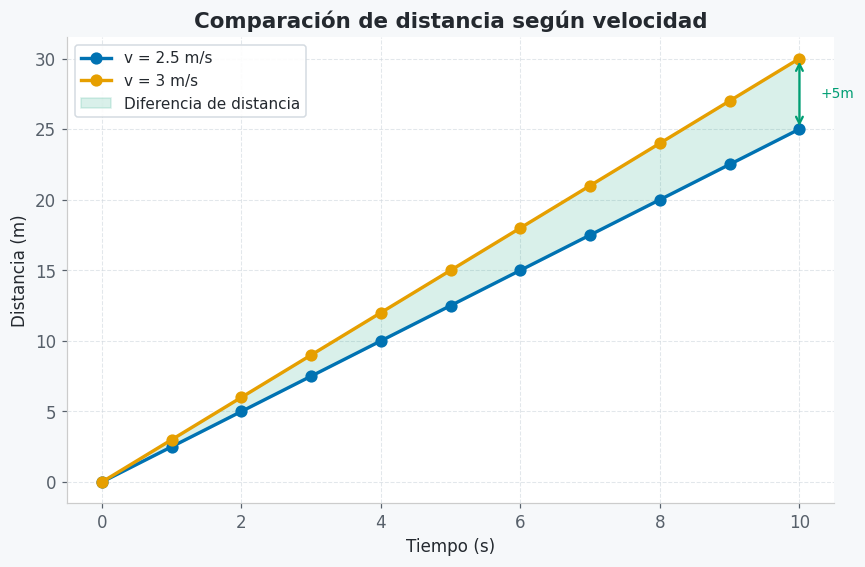

In [187]:
# Parte incluida de serie en el ejercicio.

x = np.arange(0, 11) # array con valores de 0 a 10
velocity_30 = 3
distance_30 = velocity_30 * x

# Mi parte del código abajo ----------------------------------------------------------------------------------------------------------------------------------


# Acabo de pensar en meter la comparación directamente en el gráfico que es lo que supongo que me pedirían en un trabajo. Para ello necesito nuevas variables.
# Así que he cambiado la variable 'velocity' en el gráfico anterior a 'velocity_25' y la de este ejercicio igual, le he puesto 'velocity_30'.

# Aqui hagoo un print para mostrar la respuesta del ejercicio.
print("Al aumentar la velocidad, la pendiente de la recta augmenta de valor linealmente, como se puede ver en el gráfico.\n")


# Metemos la recta de 'v=2.5m/s'.
plt.plot(x, distance_25, label='v = 2.5 m/s', marker='o')


# Metemos la recta de 'v=3m/s'.
plt.plot(x, distance_30, label='v = 3 m/s', marker='o')


# Añadimos un relleno con opacidad baja para representar la diferencia.
plt.fill_between(x, distance_25, distance_30, alpha=0.15, color='#009E73', label='Diferencia de distancia')


# Ponemos una flecha desde los 25m de la primera recta hasta los 30m de la segunda recta.
plt.annotate('', xy=(10, distance_30[-1]), xytext=(10, distance_25[-1]), arrowprops=dict(arrowstyle='<->', color='#009E73', lw=1.5))


# Ponemos un texto entre los ultimos valores dibujados en las rectas
plt.text(10.3, (distance_25[-1] + distance_30[-1]) / 2, '+5m', va='center', fontsize=9, color='#009E73')


plt.title('Comparación de distancia según velocidad')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.show()

## Ejercicio 2 - Representar visualmente datos categóricos.

Imagina que estás analizando cuántos estudiantes están matriculados en distintas carreras dentro de una universidad. Estos datos, que representan **categorías** (las carreras), son ideales para visualizar usando un **gráfico de barras**.

A continuación, se presenta un pequeño conjunto de datos con la cantidad de estudiantes por carrera.

In [188]:
# Aquí he metido los colores que quiero utilizar en el DataFrame para el punto 3 del ejercicio siguiente.

df_carreras = pd.DataFrame({
    'Carrera': ['Ingeniería', 'Medicina', 'Derecho', 'Psicología'],
    'Estudiantes': [120, 80, 60, 100],
    'Colores': ['#0072B2', '#E69F00', '#009E73', '#CC79A7']
})

df_carreras

,Carrera,Estudiantes,Colores
0,Ingeniería,120,#0072B2
1,Medicina,80,#E69F00
2,Derecho,60,#009E73
3,Psicología,100,#CC79A7


1. Representa gráficamente cuántos estudiantes hay en cada carrera y utiliza un gráfico de barras vertical con Matplotlib. 
2. Etiqueta los ejes correctamente y agrega un título descriptivo.
3. Usa un color que ayude a destacar las diferencias entre categorías.



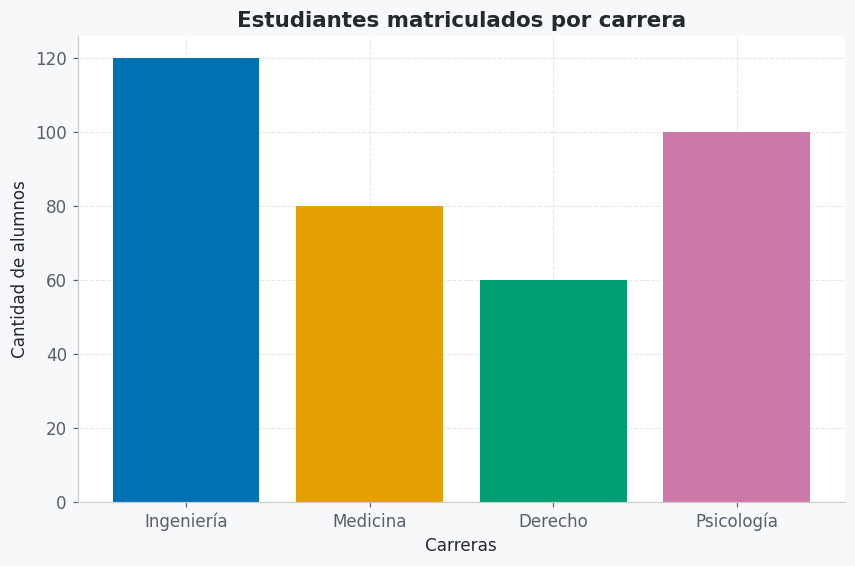

In [189]:
# 1 - Representamos gráficamente cuántos estudiantes hay en cada carrera con Matplotlib.
plt.bar(df_carreras['Carrera'], df_carreras['Estudiantes'], color=df_carreras['Colores'])


# 2 - Etiquetamos los ejes y el título de manera descriptiva.
plt.title('Estudiantes matriculados por carrera')
plt.xlabel('Carreras')
plt.ylabel('Cantidad de alumnos')


# 3 - Usar un color para cada categoría.
# Primero he metido en el 'DataFrame' la clave 'Colores' con la lista de 4 para llamoorlos luego desde 'plt.bar(color=df_carreras['Colores'])'.

# Mostramos el gráfico.
plt.show()

### ¿Qué pasaría si usás un gráfico de barras **horizontal**? ¿Te resulta más legible? Intenta hacerlo

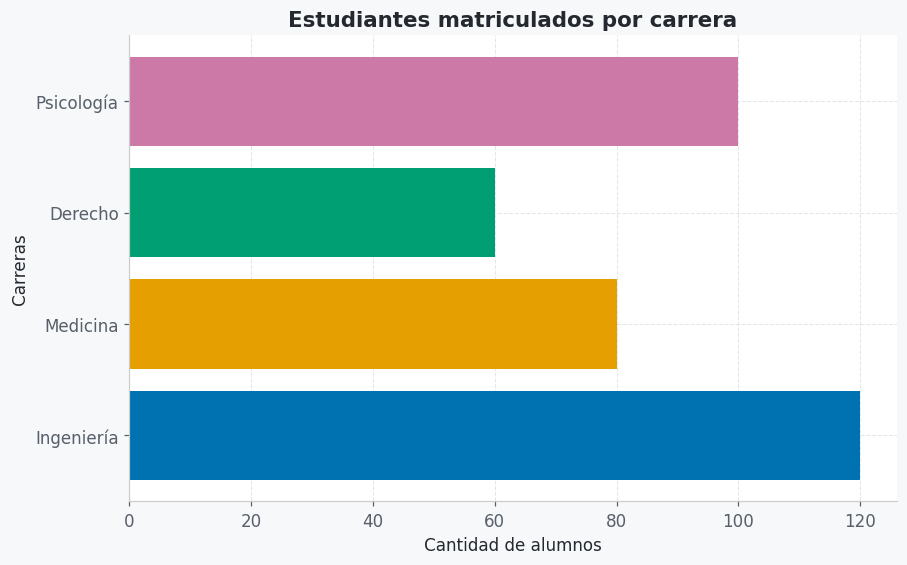

In [190]:
# Si utilizo un gráfico de barras horizontal la verdad es que lo veo mucho mejor.

plt.barh(df_carreras['Carrera'], df_carreras['Estudiantes'], color=df_carreras['Colores'])
plt.title('Estudiantes matriculados por carrera')
plt.xlabel('Cantidad de alumnos')
plt.ylabel('Carreras')
plt.show()

## Ejercicio 3: Visualizar proporciones con un gráfico circular.

Supongamos que deseas entender cómo se distribuyen los estudiantes entre distintas carreras en una universidad. Aunque ya representaste estos datos con un gráfico de barras, ahora quieres ver **qué porcentaje del total representa cada carrera**.

Una forma muy común de representar proporciones es usando un **gráfico de pastel (pie chart)**, ya que permite tener una visión rápida e intuitiva de cómo se divide el todo.


- Representa los datos de `df_carreras` como un gráfico de pastel.
- Muestra el **porcentaje** que representa cada carrera sobre el total.
- Agrega un **título descriptivo** que explique qué se está visualizando.

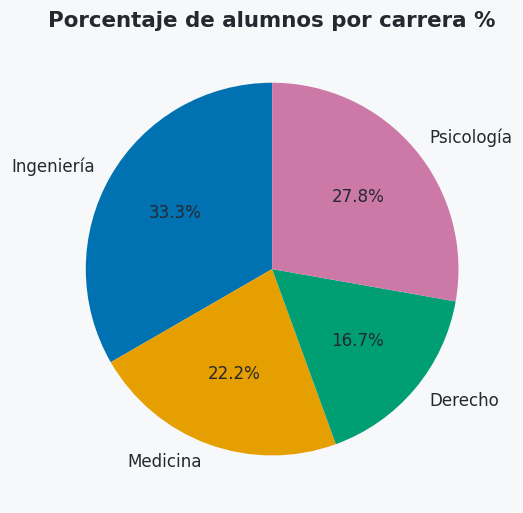

In [191]:
# Con 'plt.pie()' es la forma de representar los datos en un gráfico de pastel.


# Para mosttrar el porcentaje utilizo el "autopct='%1.1f%%'"
plt.pie(df_carreras['Estudiantes'], startangle=90, labels=df_carreras['Carrera'], autopct='%1.1f%%', colors=df_carreras['Colores'])


# El título se agrega con el mísmo método de Matplotlib que en los gráficos anteriores.
plt.title('Porcentaje de alumnos por carrera %')
plt.show()

## Ejercicio 4 - Explorar la relación entre dos variables numéricas creando un gráfico de dispersión con Seaborn

Imagina que estás analizando las características de distintas especies de flores. Cada flor tiene varias medidas:

- Largo del sépalo
- Ancho del sépalo
- Largo del pétalo
- Ancho del pétalo
- Especie a la que pertenece

Una excelente forma de **visualizar la relación entre dos variables numéricas** es mediante un **gráfico de dispersión** (`scatter plot`).

En este caso, vamos a explorar si existe una relación entre el `largo` y el `ancho` del sépalo, y si esta varía según la especie de la flor.


In [192]:
df_iris = pd.DataFrame({ # DataFrame con datos aleatorios
    'sepal_length': np.random.normal(5.8, 0.4, 150),
    'sepal_width': np.random.normal(3.0, 0.3, 150),
    'petal_length': np.random.normal(3.7, 1.5, 150),
    'petal_width': np.random.normal(1.2, 0.8, 150),
    'species': np.random.choice(['setosa', 'versicolor', 'virginica'], 150)
})

df_iris # Mostrar DataFrame

,sepal_length,sepal_width,petal_length,petal_width,species
0,6.305945,3.259540,2.830433,2.635184,virginica
1,5.418397,3.067886,3.678491,-0.986553,versicolor
2,6.043910,3.140276,2.050776,1.533952,setosa
3,6.347268,3.219007,3.948051,0.920944,setosa
4,5.802238,2.740349,1.826194,1.126265,versicolor
...,...,...,...,...,...
145,5.851338,3.101321,1.948447,0.417803,setosa
146,5.715496,2.577149,3.516657,-0.780830,virginica
147,5.827540,3.199709,2.174549,0.737092,versicolor
148,6.387814,2.863270,3.374718,1.235823,setosa


1. Crea un gráfico de dispersión con `sepal_length` en el eje X y `sepal_width` en el eje Y.
2. Usa el argumento `hue` para diferenciar las especies de flores.
3. Agrega un título descriptivo.
4. Ajusta el tamaño de los puntos o la paleta de colores para que el gráfico sea más claro. **(Opcional)**

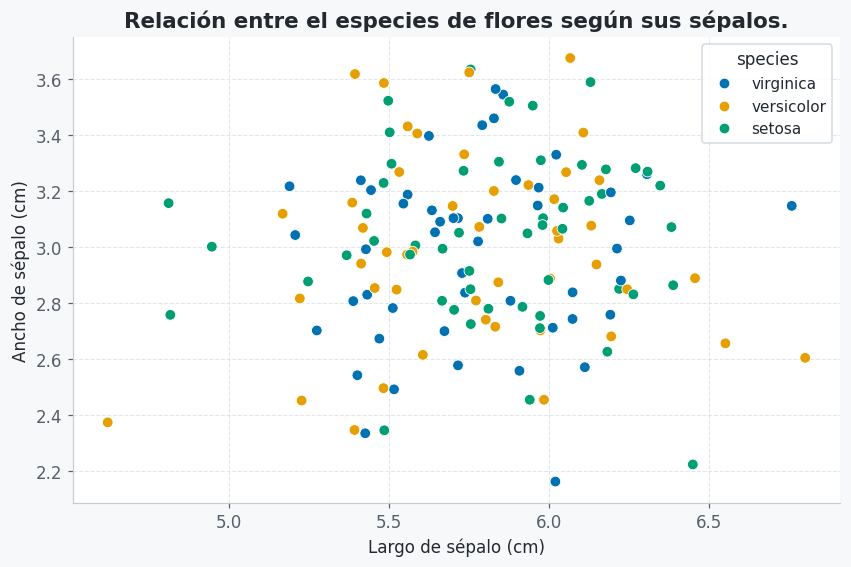

In [193]:
# 1 - En este ejercicio tenemos que crear un gráfico de dispersión con 'sepal_length' y 'sepal_width'.


# 2 - Con el argumento 'hue=' diferenciamos por especies de flores.
sns.scatterplot(df_iris, x='sepal_length', y='sepal_width', hue='species')


# 3 - Agregamos un título descriptivo.
plt.title("Relación entre el especies de flores según sus sépalos.")
plt.xlabel('Largo de sépalo (cm)')
plt.ylabel('Ancho de sépalo (cm)')


# 4 - Podríamos separar por el largo de los sépalos con 'size=df_iris['sepal_length']' pero para mi gusto sobrecarga demasiado el gráfico
# y con la separación por colores me gusta más cómo se muestra el gráfico.
# La paleta de colores está gestionada con el 'plt.style.use('./axelinvest.mplstyle')' que asignamos al inicio del código.
plt.show()

## Ejercicio 5 - Visualización de distribuciones con histogramas

En muchos casos, no solo nos interesa el valor de una variable, sino **cómo se distribuyen** esos valores.

Los histogramas son una herramienta visual muy útil para:

- Ver si los datos están **centrados** o dispersos.
- Detectar **asimetrías** (por ejemplo, si hay más valores bajos o altos).
- Identificar posibles **valores atípicos** (*outliers*).
- Observar la **forma general** de la distribución (normal, sesgada, bimodal, etc.).

Vamos a explorar cómo se distribuye el **largo del pétalo** (`petal_length`) en un conjunto de datos de flores.

In [194]:
df_iris.head() # Mostrar DataFrame

,sepal_length,sepal_width,petal_length,petal_width,species
0,6.305945,3.259540,2.830433,2.635184,virginica
1,5.418397,3.067886,3.678491,-0.986553,versicolor
2,6.043910,3.140276,2.050776,1.533952,setosa
3,6.347268,3.219007,3.948051,0.920944,setosa
4,5.802238,2.740349,1.826194,1.126265,versicolor


1. Crea un **histograma con `Seaborn`** para visualizar la distribución del largo del pétalo (`petal_length`).
2. Ajusta el número de *bins* para tener mayor o menor nivel de detalle.
3. Agrega título, etiquetas y un estilo visual claro.

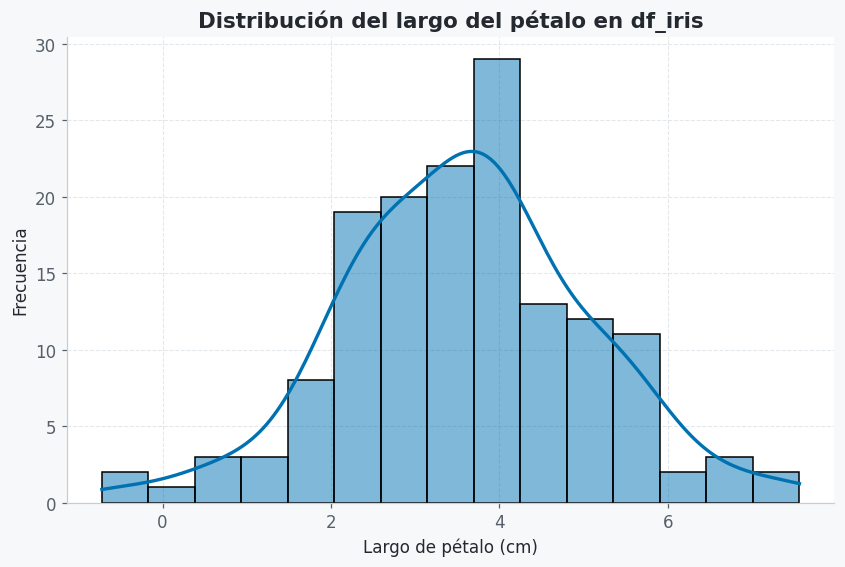

In [195]:
# Puntos 1 y 2 - Creamos el histograma con 'Seaborn' ajustando el nivel de 'bins' a 15 porque para mi gusto es suficiente detalle sin que el gráfico se vea ruidoso. 
# Además con kde=True añado la curva suavizada encima para ver directamente la forma general de la distribución.
sns.histplot(df_iris, x='petal_length', bins=15, kde=True)

# 3 - Agregamos título, etiquetas y el estilo de 'axelinvest.mplstyle'.
plt.title('Distribución del largo del pétalo en df_iris')
plt.xlabel('Largo de pétalo (cm)')
plt.ylabel('Frecuencia')
plt.show()

## Comparación por especie (distribuciones múltiples)

Ahora, compara la distribución del largo del pétalo para cada especie de flor usando `Seaborn` y el argumento `hue`.

Esto te permitirá analizar si hay **diferencias significativas** entre los grupos.

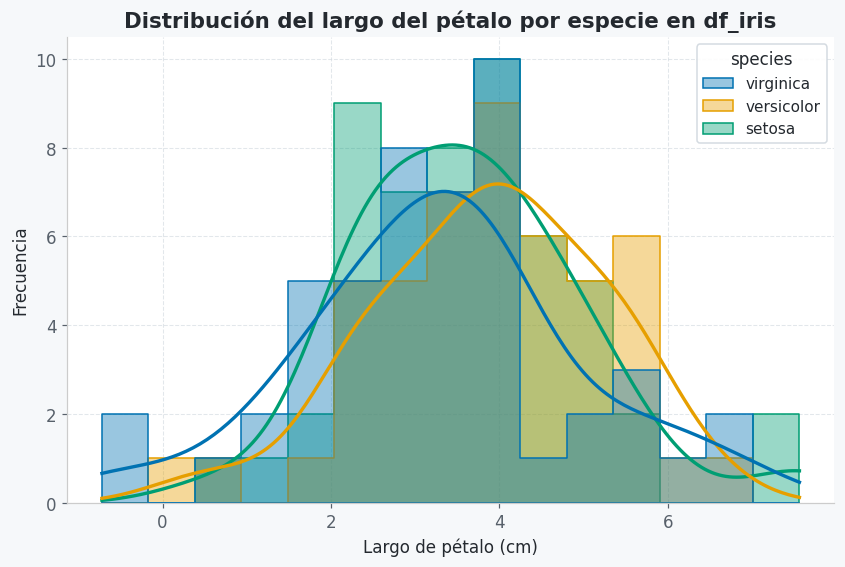

In [196]:
# En el histograma no me gusta como se ven las barras. He ajustado el 'alpha' y he visto que con "element='step'" directamente se dibuja la línea de contorno general en vez de las barras.

sns.histplot(df_iris, x='petal_length', hue='species', bins=15, element='step', alpha=0.4, kde=True)
plt.title('Distribución del largo del pétalo por especie en df_iris')
plt.xlabel('Largo de pétalo (cm)')
plt.ylabel('Frecuencia')
plt.show()

## Ejercicio 6 - Visualización de relaciones con mapas de calor (heatmap)

En ciencia de datos es importante comprender cómo se relacionan las variables entre sí. Una forma visual de hacerlo es usando mapas de calor, especialmente sobre matrices de correlación.

En este ejercicio vamos a visualizar cómo se relacionan las variables numéricas del conjunto `df_iris`.



1. Crea un mapa de calor que muestre la correlación entre las variables numéricas del DataFrame `df_iris`.Primero necesitas calcular la matriz de correlación usando `.corr()`.
2. Usa la librería **seaborn** para graficar el heatmap.
3. Activa la visualización de los valores dentro del gráfico `(annot=True)`.

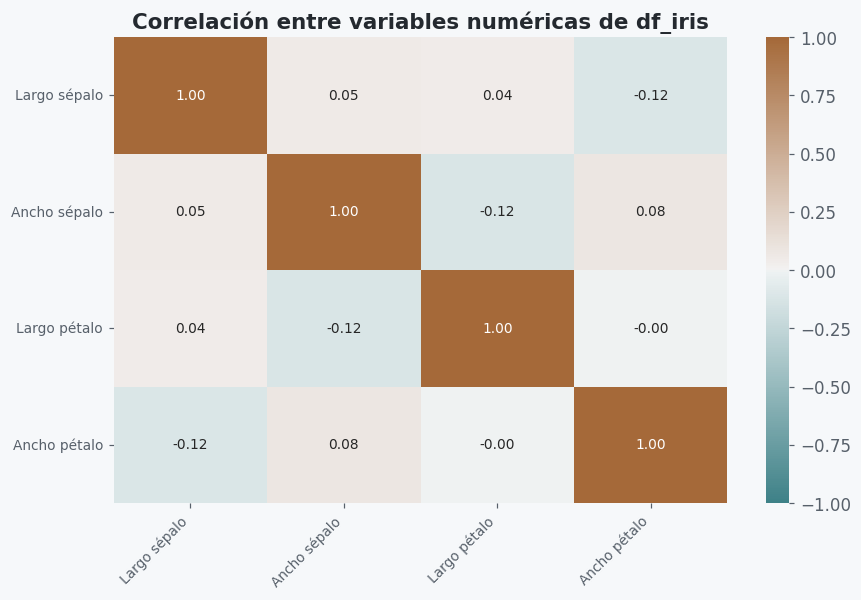

In [197]:
df_iris

# 1 - Calculamos la matriz de correlación. He visto que hay que seleccionar solo columnas numéricas
# porque .corr() falla si le pasas strings. Esto se hace con '.select_dtypes(include='number')'.
corr_matrix = df_iris.select_dtypes(include='number').corr()

# 2 y 3 - Graficamos el heatmap con Seaborn y annot=True para ver los valores dentro.
# A parte no me gusta la paleta de colores porque no se lee claro así que investigando por internet he visto que se puede meter un 'cmap=' que seria un colormap.
# Ponemos el centro del colormap en 0 con 'center=0'.
# Para que el 'termómetro' a la derecha del gráfico muestre todo el rango de colores desde 1.0 hasta -1.0 añadimos los parámetros 'vmin=-1' y 'vmax=1'.
# Ajustamos el tamaño de los números dentro de las celdas con 'annot_kws={'size': 9}'.

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=okabe_div,  center=0, vmin=-1, vmax=1,
            xticklabels=['Largo sépalo', 'Ancho sépalo', 'Largo pétalo', 'Ancho pétalo'],                                                                                                
            yticklabels=['Largo sépalo', 'Ancho sépalo', 'Largo pétalo', 'Ancho pétalo'], annot_kws={'size': 9})

plt.title('Correlación entre variables numéricas de df_iris')

# Con 'plt.tick_params(labelsize=9), ajustamos el tamaño del texto.
plt.tick_params(labelsize=9)


# Para cambiar los labels en este caso he visto que no son 'labels' sinó 'ticks'. Les he dado formato y en el caso de los 'xticks' los he rotado y los he alineado del lado derecho con "ha='right'".
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

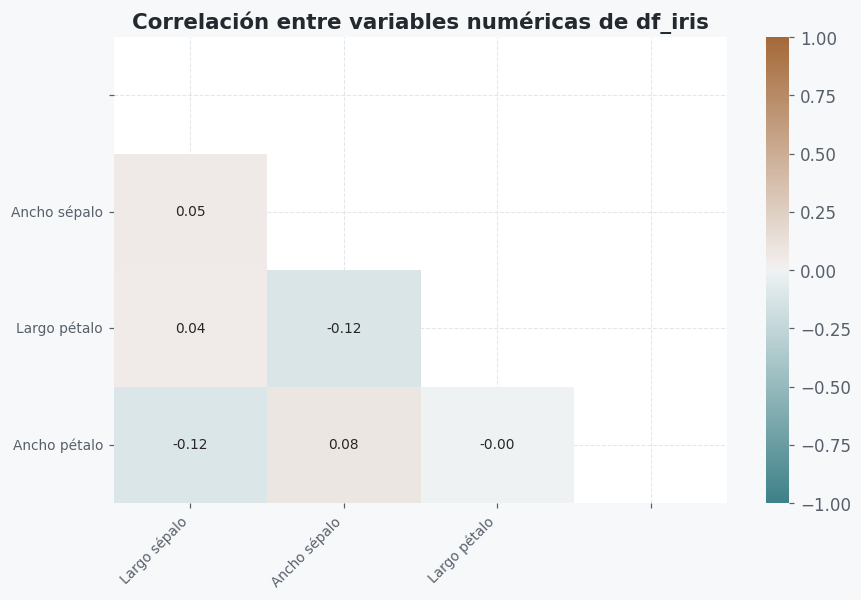

In [198]:
# Al acabar el gráfico superior, he visto que para mi es irreelevante que se muestre que la correlación entre 'petal_length' == a 'petal_length'.
# He estado investigando y los expertos en visualización de datos, a veces, ocultan estos datos. Además como el triánguloo superior y el inferior son simétricos,
# muestran solo la información inferior, ocultando toda la información redundante.

# 'np.triu()' crea una mascara para tapar estos datos. Hay que crear una máscara.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Si quisiéramos tapar la parte de abajo utilizariamos 'np.tril()'

# A partir de aqui el proceso de visualizar el gráfico es similar, solo que añadiendo el parámetro 'mask=mask'.
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=okabe_div,  center=0, vmin=-1, vmax=1,
            xticklabels=['Largo sépalo', 'Ancho sépalo', 'Largo pétalo', ''],                                                                                                
            yticklabels=['', 'Ancho sépalo', 'Largo pétalo', 'Ancho pétalo'], annot_kws={'size': 9})
plt.title('Correlación entre variables numéricas de df_iris')
plt.tick_params(labelsize=9)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

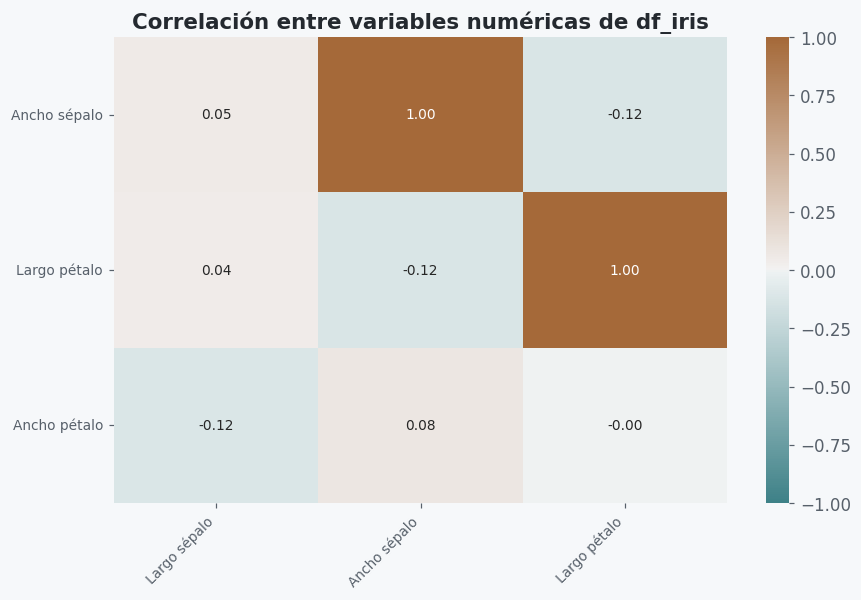

In [199]:
# Otra forma es directamente quitar esas filas y columnas antes de graficar.
# Para 'papers' esta forma suele quedar mejor.

corr_trimmed = corr_matrix.iloc[1:, :-1]
sns.heatmap(corr_trimmed, annot=True, fmt='.2f', cmap=okabe_div,  center=0, vmin=-1, vmax=1,
            xticklabels=['Largo sépalo', 'Ancho sépalo', 'Largo pétalo'],                                                                                                
            yticklabels=['Ancho sépalo', 'Largo pétalo', 'Ancho pétalo'], annot_kws={'size': 9})
plt.title('Correlación entre variables numéricas de df_iris')
plt.tick_params(labelsize=9)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

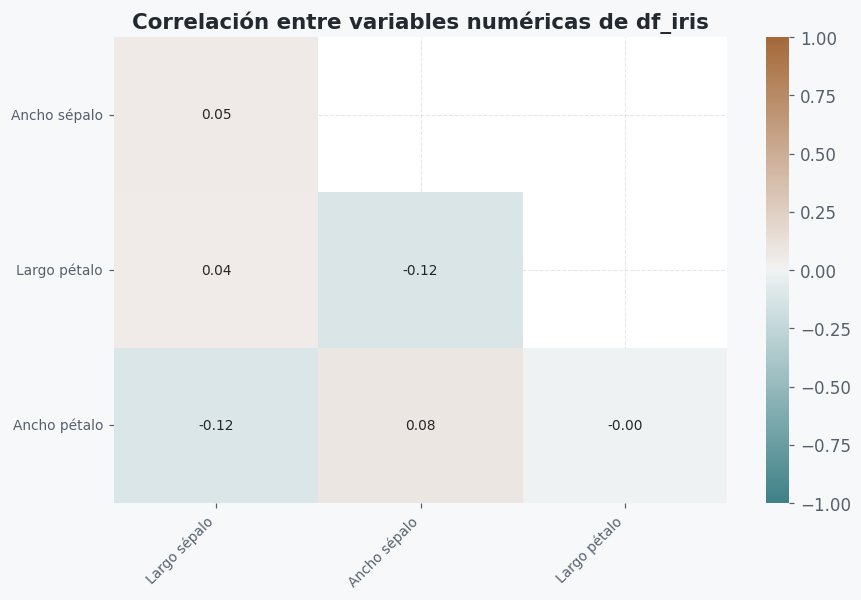

In [200]:
# Necesitamos .copy() porque vamos a modificar el DataFrame después y sin él estaríamos tocando el corr_matrix original.                                                                                                                                                                     
corr_trimmed = corr_matrix.iloc[1:, :-1].copy()

# Al cortar el DataFrame, la diagonal original (sepal_width * sepal_width, petal_length * petal_length) queda incluida dentro de la submatriz.
# La reemplazamos por NaN para que el heatmap las muestre como celdas vacías.
# Esto ya es mucho más avanzado a mi nivel, así que lo guardo en el proyecto a modo de apunte.
for var in corr_trimmed.index:
    for c in corr_trimmed.columns:
        if corr_matrix.columns.get_loc(c) >= corr_matrix.index.get_loc(var):
            corr_trimmed.loc[var, c] = np.nan


sns.heatmap(corr_trimmed, annot=True, fmt='.2f', cmap=okabe_div, center=0, vmin=-1, vmax=1,
            xticklabels=['Largo sépalo', 'Ancho sépalo', 'Largo pétalo'],
            yticklabels=['Ancho sépalo', 'Largo pétalo', 'Ancho pétalo'], annot_kws={'size': 9})
plt.title('Correlación entre variables numéricas de df_iris')
plt.tick_params(labelsize=9)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Ejercicio 7 - Visualización de la distribución por categorías con boxplot

El boxplot (o diagrama de caja) permite comparar cómo se distribuye una variable numérica según distintas categorías.

Vamos a comparar la distribución del largo del pétalo (petal_length) entre las distintas especies de flores del conjunto `df_iris`. La idea es que grafiques un boxplot que compare el largo del pétalo (`petal_length`) entre las diferentes especies (species).


1. Usa `seaborn.boxplot()` indicando el eje `x` con la especie y `y` con el largo del pétalo.
2. Es recomendable usar plt.figure() para ajustar el tamaño del gráfico si es necesario.

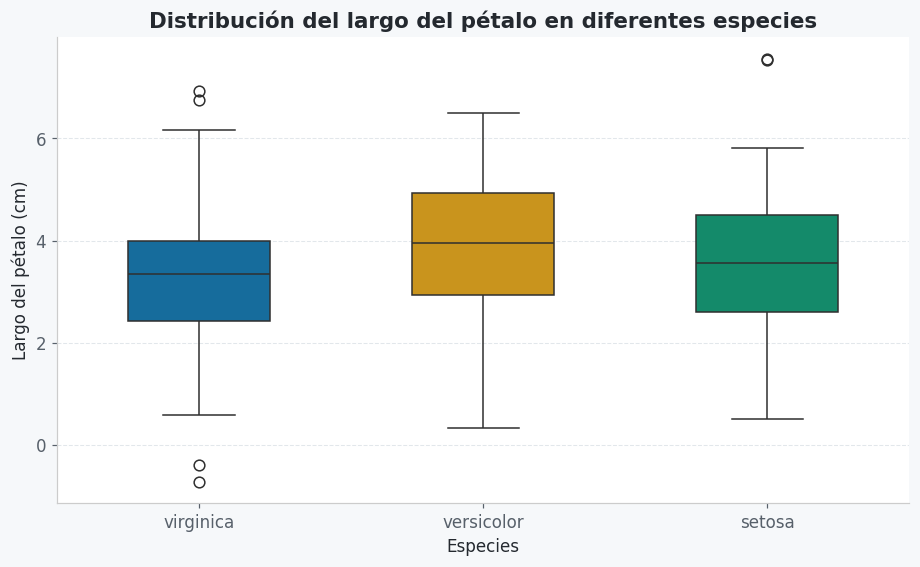

In [201]:
# Puntos 1 y 2 - Usamos '.boxplot()', a parte usamos 'plt.figure()' para ajustar el gráfico.
plt.figure(figsize=(10, 5.5))

# El ancho de las velas no me gustaba así que he encontrado que se puede ajustar con 'width='.
sns.boxplot(df_iris, x='species', y='petal_length', hue='species', width=0.5)
plt.title('Distribución del largo del pétalo en diferentes especies')
plt.xlabel('Especies')
plt.ylabel('Largo del pétalo (cm)')
plt.show()